# CIFAR-10 with PyTorch
Load local CIFAR-10 batch files from `cifar-10-batches-dataset`, convert them to PyTorch tensors, and visualize samples.

In [1]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch

In [2]:
np.random.seed(7)
torch.manual_seed(0)

In [3]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

In [4]:
base = Path('cifar-10-batches-dataset')

def load_batch(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

# Load training data
train_tensors = []
train_labels = []
for i in range(1, 6):
    batch = load_batch(base / f'data_batch_{i}')
    images = np.asarray(batch['data'], dtype=np.uint8)
    images = torch.from_numpy(images).view(-1, 3, 32, 32).float() / 255.0
    labels = torch.tensor(batch['labels'], dtype=torch.long)
    train_tensors.append(images)
    train_labels.append(labels)

train_data = torch.cat(train_tensors, dim=0)
train_labels = torch.cat(train_labels, dim=0)

# Load test data
test_batch = load_batch(base / 'test_batch')
test_images = np.asarray(test_batch['data'], dtype=np.uint8)
test_data = torch.from_numpy(test_images).view(-1, 3, 32, 32).float() / 255.0
test_labels = torch.tensor(test_batch['labels'], dtype=torch.long)

# Load label names
with open(base / 'batches.meta', 'rb') as f:
    label_names = pickle.load(f, encoding='latin1')['label_names']

print('Data loaded successfully!')
print('train_data:', train_data.shape, train_data.dtype)
print('test_data:', test_data.shape, test_data.dtype)


Data loaded successfully!
train_data: torch.Size([50000, 3, 32, 32]) torch.float32
test_data: torch.Size([10000, 3, 32, 32]) torch.float32


In [5]:
class CIFAR10Dataset(Dataset):
    """
    Custom CIFAR-10 Dataset class for PyTorch.
    Loads CIFAR-10 images and labels, with optional transforms.
    """
    def __init__(self, images, labels, label_names=None, transform=None):
        """
        Args:
            images: torch.Tensor of shape (N, 3, 32, 32) with pixel values in [0, 1]
            labels: torch.Tensor of shape (N,) with class indices
            label_names: list of class names (optional)
            transform: optional callable that transforms image tensors
        """
        self.images = images
        self.labels = labels
        self.label_names = label_names
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Create train and test datasets
train_dataset = CIFAR10Dataset(train_data, train_labels, label_names=label_names)
test_dataset = CIFAR10Dataset(test_data, test_labels, label_names=label_names)

print('CIFAR10Dataset instances created!')
print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')
print(f'Sample item: image shape={train_dataset[0][0].shape}, label={train_dataset[0][1].item()}')


CIFAR10Dataset instances created!
Train dataset size: 50000
Test dataset size: 10000
Sample item: image shape=torch.Size([3, 32, 32]), label=6


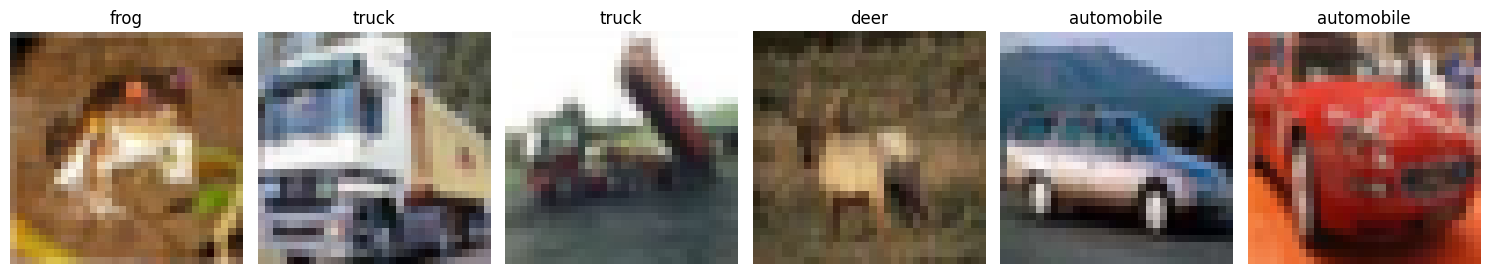


Dataset Statistics:
Total training samples: 50000
Total test samples: 10000

Class distribution:
  0: airplane   -> train:  5000, test:  1000
  1: automobile -> train:  5000, test:  1000
  2: bird       -> train:  5000, test:  1000
  3: cat        -> train:  5000, test:  1000
  4: deer       -> train:  5000, test:  1000
  5: dog        -> train:  5000, test:  1000
  6: frog       -> train:  5000, test:  1000
  7: horse      -> train:  5000, test:  1000
  8: ship       -> train:  5000, test:  1000
  9: truck      -> train:  5000, test:  1000


In [6]:
# Visualize sample images from the dataset
def show_dataset_samples(dataset, n=6):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        image, label = dataset[i]
        img = image.cpu().numpy()
        img = np.transpose(img, (1, 2, 0))
        axes[i].imshow(img)
        label_name = dataset.label_names[label.item()] if dataset.label_names else str(label.item())
        axes[i].set_title(label_name)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_dataset_samples(train_dataset, n=6)

# Dataset statistics
print('\nDataset Statistics:')
print(f'Total training samples: {len(train_dataset)}')
print(f'Total test samples: {len(test_dataset)}')
print('\nClass distribution:')
train_counts = torch.bincount(train_labels, minlength=10)
test_counts = torch.bincount(test_labels, minlength=10)
for idx, name in enumerate(label_names):
    print(f'  {idx}: {name:10s} -> train: {train_counts[idx].item():5d}, test: {test_counts[idx].item():5d}')
